In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import torch
import torch._dynamo
# Suppress torch._dynamo compilation errors and fall back to eager mode
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

from pathlib import Path
import os
import pickle
import math
import string
from collections import OrderedDict
sys.path.append(str(Path.cwd().parent))
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
def plot_multiple_regression_series(data_dicts, titles=None, save_path=None, verbose=False):
    """
    data_dicts: list of data_dict, where each data_dict has the structure {label: (true_vals, pred_vals)}
    titles: list of str, corresponding to the subplot titles for each data_dict
    """
    n = len(data_dicts)
    cols = 2 if n > 1 else 1
    rows = math.ceil(n / cols)   
    
    fig, axs = plt.subplots(rows, cols, figsize=(8*cols, 5*rows), squeeze=False)
    axs = axs.ravel()

    all_handles, all_labels = [], []  

    for i, data_dict in enumerate(data_dicts):
        ax = axs[i]
        idx_start = 0
        for label, (true_vals, pred_vals) in data_dict.items():
            n_pts = len(true_vals)
            idx_range = np.arange(idx_start, idx_start + n_pts)

            h1, = ax.plot(idx_range, true_vals, label=f'{label} - True')
            h2, = ax.plot(idx_range, pred_vals, linestyle='--', label=f'{label} - Predicted')

            idx_start += n_pts

            all_handles.extend([h1, h2])
            all_labels.extend([h1.get_label(), h2.get_label()])

        ax.set_xlabel("Sample Index", fontsize=10)
        ax.set_ylabel("Magnitude", fontsize=10)
        if titles is not None and i < len(titles):
            ax.set_title(titles[i], fontsize=12)
        ax.grid(True)

        label = f"({string.ascii_lowercase[i]})"
        ax.text(
            0.98, 0.05, label,
            transform=ax.transAxes, 
            ha="right", va="bottom",
            fontsize=12, fontweight="medium"  
        )

    uniq = dict(zip(all_labels, all_handles))
    fig.legend(uniq.values(), uniq.keys(), loc="lower center", ncol=3, fontsize=10)

    plt.tight_layout(rect=[0,0.05,1,1])  
    if save_path:
        plt.savefig(save_path, dpi=300)
        if verbose:
            print(f"[✔] Saved series plots to {save_path}")
    plt.show()


In [3]:
from  src.train.config_setup import load_and_prepare_model
from src.data.preparation import prepare_data, prepare_data_lstm  
from src.train.regressor_train_step import  get_data_dict
def get_data_dict_from_checkpoint(checkpoint_path_list, device, prepare_data_func, shared_data=None):
    """
    Given a list of checkpoint paths, load each model and prepare the data dictionary.
    If `shared_data` is provided, reuse it to avoid preparing the same dataset multiple times.
    Returns: (data_dict_list, shared_data) so callers can pass `shared_data` to subsequent calls.
    """
    data_dict_list = []
    for checkpoint_path in checkpoint_path_list:
        model, args = load_and_prepare_model(checkpoint_path=checkpoint_path, device=device, compile=False)
       
        if shared_data is None:
            df, train_loader, val_loader, test_loader, catalog_ds = prepare_data_func(
                base_dir=f"../data/{args.dataset}", args=args
            )
            shared_data = (train_loader, val_loader, test_loader)
        train_loader, val_loader, test_loader = shared_data
        data_dict = get_data_dict([train_loader, val_loader, test_loader], model, device)
        data_dict_list.append(data_dict)
        del model
        torch.cuda.empty_cache()

    return data_dict_list, shared_data

In [4]:
checkpoint_path_lstm = [
     Path("../checkpoints/lstm_20250906-152053/last_model_1.pth"),
    
]
checkpoint_path_reg1 = [
    Path("../checkpoints/reg_mixer_attnpl_t_20260204-180531/last_model_1.pth"),
    # Path("../checkpoints/reg_mixer_attnpl_t_20260204-195612/last_model_1.pth"),
    # Path("../checkpoints/reg_mixer_attnpl_t_20260204-201607/last_model_1.pth"),
    # Path("../checkpoints/reg_mixer_attnpl_t_20260204-194201/last_model_1.pth"),
    # Path("../checkpoints/reg_mixer_attnpl_t_20260204-192629/last_model_1.pth")
]
checkpoint_path_reg2 = [
    # Path("../checkpoints/reg_mixer_attnpl_t_20260204-180531/last_model_1.pth"),
    Path("../checkpoints/reg_mixer_attnpl_t_20260204-195612/last_model_1.pth"),
    Path("../checkpoints/reg_mixer_attnpl_t_20260204-201607/last_model_1.pth"),
    Path("../checkpoints/reg_mixer_attnpl_t_20260204-194201/last_model_1.pth"),
    Path("../checkpoints/reg_mixer_attnpl_t_20260204-192629/last_model_1.pth")
    # checkpoints/reg_mixer_attnpl_t_20250921-182545
]
# Prepare data dicts and reuse shared_data to avoid multiple data preparations
lstm_data_dicts, _ = get_data_dict_from_checkpoint(checkpoint_path_lstm, device, prepare_data_lstm)
reg_data_dicts1, shared_data = get_data_dict_from_checkpoint(checkpoint_path_reg1, device, prepare_data)
reg_data_dicts2, shared_data = get_data_dict_from_checkpoint(checkpoint_path_reg2, device, prepare_data, shared_data=shared_data)
data_dicts = lstm_data_dicts + reg_data_dicts1 + reg_data_dicts2

load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'lstm', 'task_type': 'regression', 'batch_size': 128, 'accumulation_steps': 1, 'warmup_ratio': 'None', 'learning_rate': 0.001, 'weight_decay': 1e-05, 'scheduler_factor': 0.6, 'scheduler_patience': 5, 'scheduler_threshold': 0.0001, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'none', 'lstm_hidden_size': 256, 'lstm_num_layers': 4, 'lstm_dropout': 0.3, 'epochs': 200, 'save_dir': 'checkpoints/lstm_20250906-152053', 'cuda_id': '0', 'dataset': 'ChuanDian', 'criterion_name': 'smooth_l1', 'criterion_cfg': {'beta': 0.5}, 'seed': 0, 'Mc': 3, 'Mf': 3, 'Mag_elaps': [6, 6.5, 7, 7.5], 'Twindow': 360, 'Tfore': 180, 'dt': 10, 'context_len': 0, 'dMag': 0.1, 'split_by_time': True, 'time_step': 5, 'feature_cols': ['Num', 'Mag_max', 'Mag_mean', 'b_lsq', 'a_lsq', 'b_std_lsq', 'std_gr_lsq', 'b_mlk', 'a_mlk', 'b_std_mlk', 'std_gr_mlk', 'dM_lsq', 'dM_mlk', 'Energy_sqrt', 'prob_x7_lsq', 'prob_x7_mlk', 'beta'

In [5]:
for x,y in shared_data[0]:
    print(x.device, y.shape)
    break

cpu torch.Size([64])


In [6]:
os.makedirs("figs_data", exist_ok=True)
with open("figs_data/reg_data_dicts.pkl", "wb") as f:
    pickle.dump(data_dicts, f)

In [7]:
with open("figs_data/reg_data_dicts.pkl", "rb") as f:  # "rb" 表示以二进制只读模式
    data_dicts = pickle.load(f)

In [8]:
data_dicts[0]['Train']

(array([5.9, 5.9, 5.9, ..., 5.4, 5.4, 5.4], dtype=float32),
 array([6.180707 , 6.2517104, 6.2878947, ..., 5.0528927, 5.0572877,
        5.057252 ], dtype=float32))

In [13]:
titles = [
    "LSTM",
    "EM-EQF",
    r"EM-EQF (+$\log(\Delta t)$)",
    "EM-EQF (-T-XPOS)",
    "EM-EQF (-TMAP)",
    "EM-EQF (-Pretrain)",
]

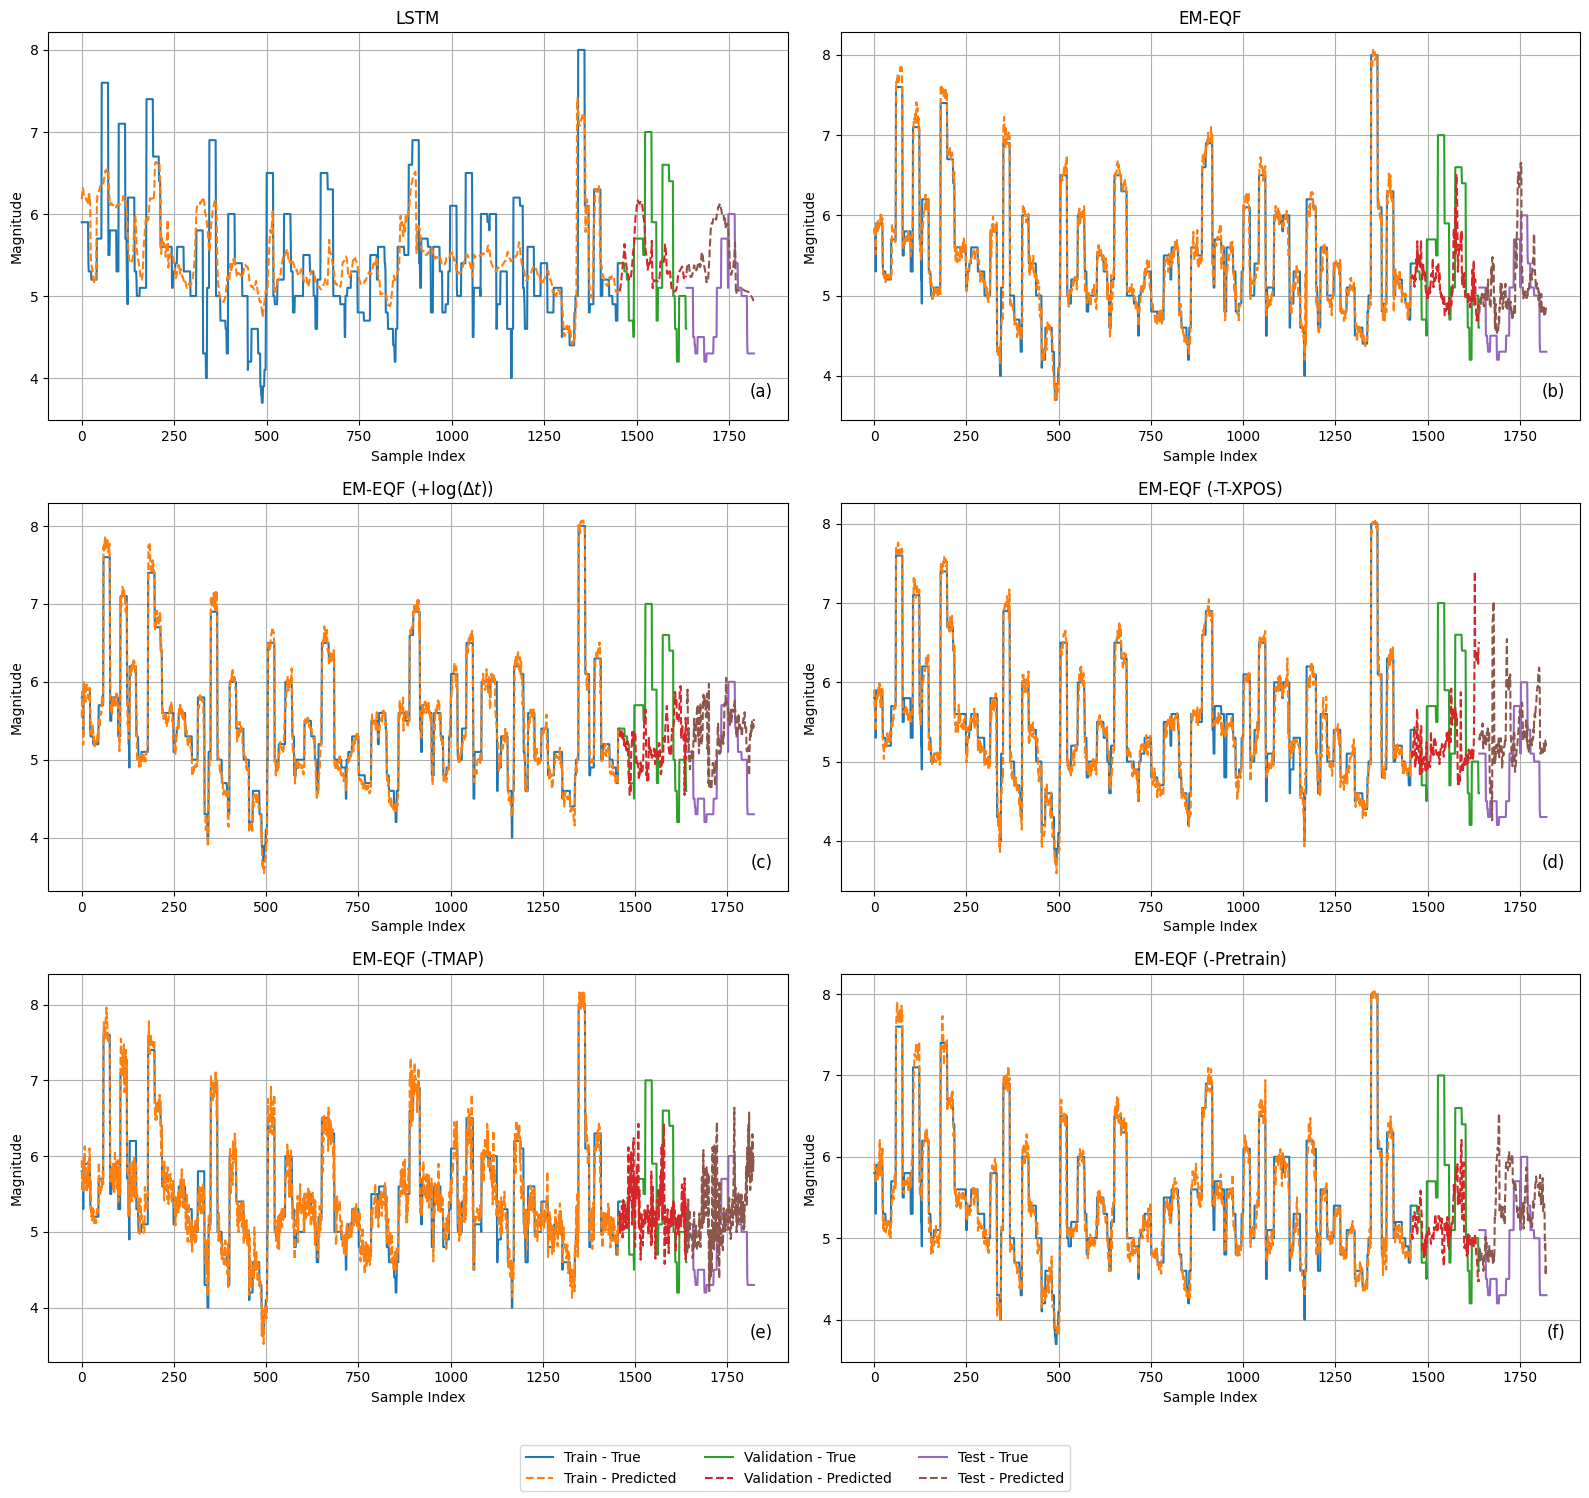

In [14]:
plot_multiple_regression_series(data_dicts , titles=titles, save_path="figs/regression_plots.pdf", verbose=False)